# Substructure Search: RDKit (CPU) vs nvMolKit (GPU)

**Tutorial 10 of the nvMolKit acceleration series.**

Substructure search screens a library of molecules for SMARTS patterns - the core of functional-group filtering,
SMARTS-based property flags, and pharmacophore pre-screens. Screening **N targets × Q queries** is a large
independent grid of matches, which nvMolKit batches across the GPU.

This notebook compares screening a molecule library against a panel of functional-group SMARTS:

- **RDKit (CPU)** — `target.HasSubstructMatch(query)` over every (target, query) pair.
- **nvMolKit (GPU)** — `nvmolkit.substructure.hasSubstructMatch(targets, queries)`, one batched call.

There are also `countSubstructMatches` (match counts) and `getSubstructMatches` (atom indices) with the same
batched API.

> **Limitation (see Section 9):** nvMolKit substructure search does **not** support chirality-aware matching, and
> in this version **recursive SMARTS** (`$(...)` environments) do not match RDKit. We use non-recursive SMARTS
> here so the comparison is exact, and demonstrate the recursive-SMARTS caveat at the end.
>
> RDKit's matching has no native threaded path, so the `rdkit_16thread` column is a 16-way **multi-process**
> baseline (consistent with Tutorials 6-8). Run from `examples/tutorials/`.


## 1. Setup and GPU check

In [1]:
import multiprocessing
import time
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import pandas as pd
import torch
from rdkit import RDLogger
from rdkit.Chem import MolFromSmiles, MolFromSmarts

import nvmolkit
from nvmolkit.substructure import hasSubstructMatch

RDLogger.DisableLog("rdApp.*")
assert torch.cuda.is_available(), "CUDA is not available - check your torch/driver install."
N_CPU_THREADS = 16   # consistent with tutorials 1-5; here a 16-process CPU baseline
print(f"nvmolkit : {nvmolkit.__version__}")
print(f"torch    : {torch.__version__}")
print(f"GPU      : {torch.cuda.get_device_name(0)}")

nvmolkit : 0.5.0
torch    : 2.12.0+cu126
GPU      : NVIDIA A100 80GB PCIe


## 2. Parameters and query panel

In [2]:
SIZES = [1000, 2000, 5000, 10000]
SMI_FILE = "../../benchmarks/data/chembl_10k.smi"

# Functional-group SMARTS (non-recursive, so RDKit and nvMolKit agree exactly)
SMARTS = [
    "c1ccccc1",        # benzene ring
    "C(=O)[OH]",       # carboxylic acid
    "C(=O)N",          # amide
    "[OH]",            # hydroxyl
    "[F,Cl,Br,I]",     # halogen
    "[N+](=O)[O-]",    # nitro
    "S(=O)(=O)N",      # sulfonamide
    "c1ccncc1",        # pyridine
    "C#N",             # nitrile
    "[CX3]=[OX1]",     # carbonyl
    "C1CCCCC1",        # cyclohexane
    "[nH]",            # aromatic NH
    "C(=O)OC",         # ester
    "[SX2]",           # divalent sulfur
    "C(=O)C",          # ketone/acyl
]
queries = [MolFromSmarts(s) for s in SMARTS]
print(f"{len(queries)} SMARTS queries, sweep sizes = {SIZES}")

15 SMARTS queries, sweep sizes = [1000, 2000, 5000, 10000]


## 3. Load target molecules

In [3]:
smis = pd.read_csv(SMI_FILE, header=None, nrows=max(SIZES)).iloc[:, 0].tolist()
targets_all = [m for m in (MolFromSmiles(s) for s in smis) if m is not None]
SIZES = [n for n in SIZES if n <= len(targets_all)]
print(f"Loaded {len(targets_all)} target molecules; sweep sizes = {SIZES}")

Loaded 10000 target molecules; sweep sizes = [1000, 2000, 5000, 10000]


## 4. Define the backends

Both produce a boolean `(n_targets, n_queries)` matrix. The 16-way baseline spreads RDKit's per-target loop
across worker processes.

In [4]:
def _rdkit_has_one(mol):
    return [mol.HasSubstructMatch(q) for q in queries]


def rdkit_has(targets):                                 # 1 thread (serial)
    return np.array([_rdkit_has_one(m) for m in targets], dtype=bool)


def rdkit_has_parallel(targets, workers=N_CPU_THREADS):  # 16-way multi-process
    ctx = multiprocessing.get_context("fork")
    with ProcessPoolExecutor(max_workers=workers, mp_context=ctx) as ex:
        rows = list(ex.map(_rdkit_has_one, targets))
    return np.array(rows, dtype=bool)


def nvmolkit_has(targets):
    res = np.asarray(hasSubstructMatch(targets, queries)).astype(bool)
    torch.cuda.synchronize()
    return res

## 5. Correctness check

With non-recursive SMARTS the boolean match matrices should be **identical**.

In [5]:
sample = targets_all[:max(SIZES)]
rd_m = rdkit_has(sample)
nv_m = nvmolkit_has(sample)

print(f"match matrix shape : {nv_m.shape}  ({rd_m.size} target-query pairs)")
print(f"identical          : {np.array_equal(rd_m, nv_m)}")
print(f"agreement          : {100 * (rd_m == nv_m).mean():.4f}%")
assert np.array_equal(rd_m, nv_m), "non-recursive SMARTS results should match exactly!"
print("\nOK - GPU substructure results are identical to RDKit for these queries.")

match matrix shape : (10000, 15)  (150000 target-query pairs)
identical          : True
agreement          : 100.0000%

OK - GPU substructure results are identical to RDKit for these queries.


## 6. Warm up the GPU

In [6]:
_ = nvmolkit_has(targets_all[:50])
print("GPU warmed up.")

GPU warmed up.


## 7. Scaling benchmark

RDKit 1-thread (serial) and 16-thread (16 processes) vs nvMolKit GPU (one batched call).

In [7]:
def timed(fn, targets):
    t = time.perf_counter()
    fn(targets)
    torch.cuda.synchronize()
    return time.perf_counter() - t


n_q = len(queries)
rows = []
for n in SIZES:
    base = targets_all[:n]
    t_rd1 = timed(rdkit_has, base)
    t_rdN = timed(rdkit_has_parallel, base)
    t_gpu = timed(nvmolkit_has, base)
    pairs = n * n_q
    rows.append({
        "n_mols": n,
        "n_queries": n_q,
        "pairs": pairs,
        "rdkit_1thread_s": t_rd1,
        "rdkit_16thread_s": t_rdN,
        "nvmolkit_gpu_s": t_gpu,
        "speedup_vs_1thread": t_rd1 / t_gpu,
        "speedup_vs_16thread": t_rdN / t_gpu,
    })
    print(f"n={n:6d} | pairs={pairs:7d} | RDKit-1t {t_rd1:6.3f}s | RDKit-16t {t_rdN:6.3f}s | "
          f"nvMolKit {t_gpu:6.4f}s | speedup {t_rd1/t_gpu:5.1f}x / {t_rdN/t_gpu:5.1f}x")

df = pd.DataFrame(rows)
df

n=  1000 | pairs=  15000 | RDKit-1t  0.058s | RDKit-16t  0.398s | nvMolKit 0.0326s | speedup   1.8x /  12.2x


n=  2000 | pairs=  30000 | RDKit-1t  0.111s | RDKit-16t  0.720s | nvMolKit 0.0463s | speedup   2.4x /  15.6x


n=  5000 | pairs=  75000 | RDKit-1t  0.258s | RDKit-16t  1.244s | nvMolKit 0.0839s | speedup   3.1x /  14.8x


n= 10000 | pairs= 150000 | RDKit-1t  0.515s | RDKit-16t  2.228s | nvMolKit 0.0916s | speedup   5.6x /  24.3x


,n_mols,n_queries,pairs,rdkit_1thread_s,rdkit_16thread_s,nvmolkit_gpu_s,speedup_vs_1thread,speedup_vs_16thread
0,1000,15,15000,0.058113,0.397960,0.032587,1.783311,12.212271
1,2000,15,30000,0.110873,0.720208,0.046260,2.396758,15.568820
2,5000,15,75000,0.258375,1.243755,0.083892,3.079830,14.825587
3,10000,15,150000,0.515185,2.228178,0.091649,5.621264,24.312011


## 8. Plot: runtime and speedup vs library size

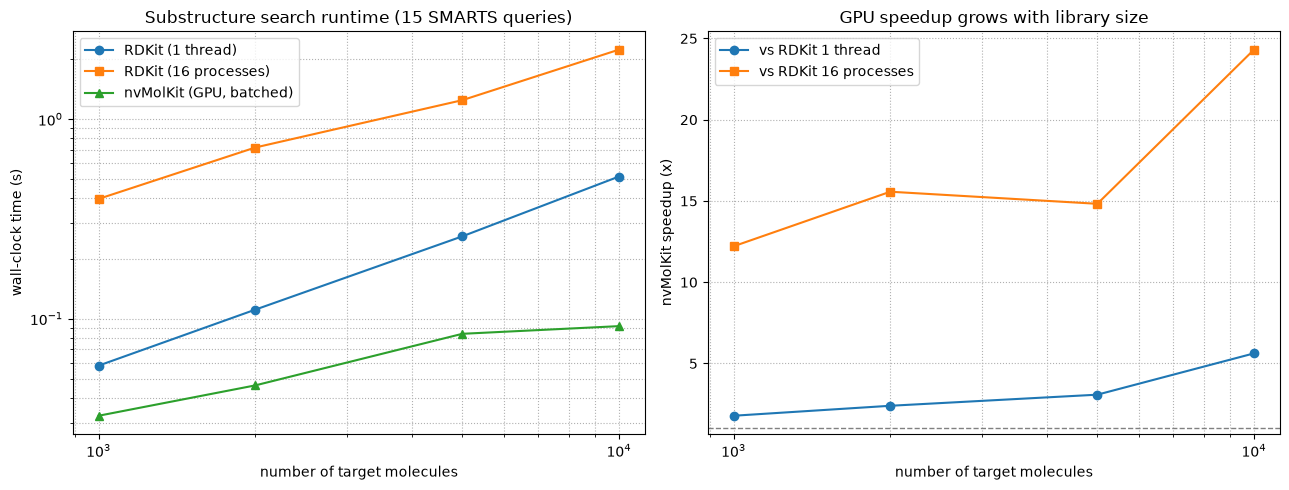

In [8]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(df["n_mols"], df["rdkit_1thread_s"], "o-", label="RDKit (1 thread)")
ax1.plot(df["n_mols"], df["rdkit_16thread_s"], "s-", label="RDKit (16 processes)")
ax1.plot(df["n_mols"], df["nvmolkit_gpu_s"], "^-", label="nvMolKit (GPU, batched)")
ax1.set_xlabel("number of target molecules")
ax1.set_ylabel("wall-clock time (s)")
ax1.set_title(f"Substructure search runtime ({len(queries)} SMARTS queries)")
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.legend(); ax1.grid(True, which="both", ls=":")

ax2.plot(df["n_mols"], df["speedup_vs_1thread"], "o-", label="vs RDKit 1 thread")
ax2.plot(df["n_mols"], df["speedup_vs_16thread"], "s-", label="vs RDKit 16 processes")
ax2.axhline(1.0, color="gray", ls="--", lw=1)
ax2.set_xlabel("number of target molecules")
ax2.set_ylabel("nvMolKit speedup (x)")
ax2.set_title("GPU speedup grows with library size")
ax2.set_xscale("log")
ax2.legend(); ax2.grid(True, which="both", ls=":")
plt.tight_layout(); plt.show()

## 9. Limitation: recursive SMARTS

The nvMolKit docs note that chirality-aware matching and advanced `SubstructMatchParameters` options are not
supported. In this version, **recursive SMARTS** (`$(...)` environments) also do not match RDKit - they should
be avoided until fixed. The cell below shows the discrepancy on a recursive query.

In [9]:
recursive = MolFromSmarts("[$(NC=O)]")   # nitrogen in an amide (recursive environment)
sample = targets_all[:2000]
rd_rec = np.array([m.HasSubstructMatch(recursive) for m in sample], dtype=bool)
nv_rec = np.asarray(hasSubstructMatch(sample, [recursive])).astype(bool).ravel()
print("Recursive SMARTS '[$(NC=O)]':")
print(f"  RDKit hits    : {int(rd_rec.sum())}")
print(f"  nvMolKit hits : {int(nv_rec.sum())}")
print(f"  agreement     : {100 * (rd_rec == nv_rec).mean():.1f}%   <-- recursive SMARTS NOT supported reliably")

Recursive SMARTS '[$(NC=O)]':
  RDKit hits    : 1138
  nvMolKit hits : 160
  agreement     : 51.1%   <-- recursive SMARTS NOT supported reliably


## 10. Takeaways

- **Exact for non-recursive SMARTS.** The GPU boolean match matrix is identical to RDKit across this
  functional-group panel.
- **Speedup grows with the screen size.** Substructure matching is cheap per pair, so the GPU advantage is more
  modest than the O(n²) operations, but it grows with the target × query grid and clearly beats a multi-process
  RDKit baseline.
- **Full API.** `hasSubstructMatch` (boolean), `countSubstructMatches` (counts), and `getSubstructMatches`
  (atom indices) share the same batched interface; tune with `SubstructSearchConfig`.
- **Known limitations.** No chirality-aware matching, and recursive SMARTS (`$(...)`) do not match RDKit in this
  version - avoid recursive patterns or verify against RDKit.

This completes the nvMolKit acceleration tutorial series (fingerprints, similarity, embedding, MMFF/UFF, batched
force fields, conformer RMSD, TFD, clustering, and substructure search).